### IMPORTING ALL THE NECCESSORY PACKAGES

In [83]:
# all important imports 
using ComponentArrays,JLD2, DataFrames, CSV, StaticArrays, SciMLSensitivity, Lux, LinearAlgebra, DifferentialEquations, Plots,Random,Convex, SCS,Printf

### LODING THE SYNTHETIC NOISY DATA

In [60]:

true_data = data_loaded = CSV.read("C:/Ude_HH_model/ude_models/noisy_data.csv", DataFrame)
y = Float32.(true_data[!, "n"])
t_steps = Float32.(true_data[!, "Time"])



3001-element Vector{Float32}:
  0.0
  0.01
  0.02
  0.03
  0.04
  0.05
  0.06
  0.07
  0.08
  0.09
  0.1
  0.11
  0.12
  ⋮
 29.89
 29.9
 29.91
 29.92
 29.93
 29.94
 29.95
 29.96
 29.97
 29.98
 29.99
 30.0

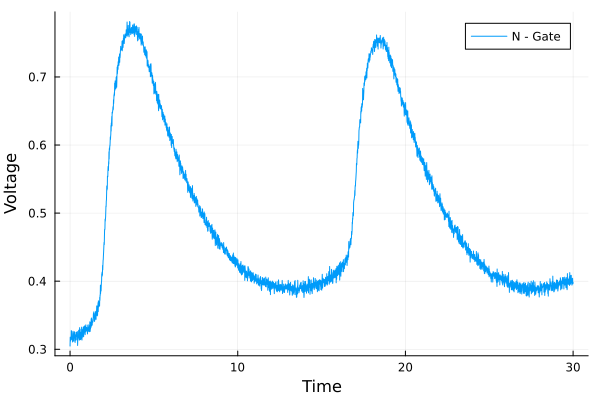

In [61]:
 plot(t_steps,y,xlabel = "Time" , ylabel ="Voltage",label ="N - Gate ")

### CREATING  A NEURAL NETWORK

In [62]:
rng = Random.seed!(42)
nn = Chain(Dense(1 => 32),
    Dense(32 => 32, tanh),
    Dense(32 => 1, sigmoid))
ps, st = Lux.setup(rng, nn)

display(nn)

Chain(
    layer_1 = Dense(1 => 32),                     # 64 parameters
    layer_2 = Dense(32 => 32, tanh),              # 1_056 parameters
    layer_3 = Dense(32 => 1, σ),                  # 33 parameters
)         # Total: 1_153 parameters,
          #        plus 0 states.

In [63]:

true_data = CSV.read("C:/Ude_HH_model/ude_models/synthetic_data.csv", DataFrame)
t_steps = Float32.(true_data[!, "Time"])
ture_n = Float32.(true_data[!, "n"])

3001-element Vector{Float32}:
 0.317
 0.31700262
 0.317008
 0.3170161
 0.31702694
 0.3170405
 0.31705678
 0.31707576
 0.3170974
 0.31712174
 0.31714872
 0.31717837
 0.31721067
 ⋮
 0.40159258
 0.4017208
 0.40184993
 0.40198
 0.40211102
 0.40224305
 0.402376
 0.40250996
 0.40264493
 0.4027809
 0.40291786
 0.40305588

### 2. Hodgkin-Huxley Model Parameters

In [64]:


const g_na = 120.0f0
const g_k = 36.0f0
const g_l = 0.3f0
const c_m = 1.0f0
const I_ext = 10.0f0
const E_na = 50.0f0
const E_k = -77.0f0
const E_l = -54.4f0

-54.4f0

### 3. Rate Functions for Gating Variables

In [65]:

alpha_n(V) = abs(V + 55.0f0) < 1.0f-6 ? 0.1f0 : 0.01f0 * (V + 55.0f0) / (1.0f0 - exp(-(V + 55.0f0) / 10.0f0))
beta_n(V) = 0.125f0 * exp(-(V + 65.0f0) / 80.0f0)

alpha_m(V) = abs(V + 40.0f0) < 1.0f-6 ? 1.0f0 : 0.1f0 * (V + 40.0f0) / (1.0f0 - exp(-(V + 40.0f0) / 10.0f0))
beta_m(V) = 4.0f0 * exp(-(V + 65.0f0) / 18.0f0)

alpha_h(V) = 0.07f0 * exp(-(V + 65.0f0) / 20.0f0)
beta_h(V) = 1.0f0 / (1.0f0 + exp(-(V + 35.0f0) / 10.0f0))

beta_h (generic function with 1 method)

### 5. Load Trained Parameters

In [92]:

ps = load("C:/Ude_HH_model/ude_models/leaning_parameter4.jld2", "p")


ComponentVector{Float32}(layer_1 = (weight = Float32[-0.6080406; -0.74058723; … ; -0.9835408; -1.5926328;;], bias = Float32[-0.13480704, 0.2704967, 0.38293415, -0.5446276, -0.74287176, 0.73560274, -0.7931213, -0.16192989, -0.2777777, -0.62861276  …  -0.30235344, -0.53258383, -0.45531702, 0.70192385, 0.76495177, -0.78717625, 0.41378036, -0.23162937, -0.8057279, 0.06428368]), layer_2 = (weight = Float32[0.47606942 -0.7872422 … 0.118564636 0.2927078; -0.123785816 -0.79414946 … 0.2671326 0.204071; … ; -0.3257922 -0.4512257 … 0.1688862 -0.22592719; -0.45250383 0.63275087 … 0.34904778 0.33413628], bias = Float32[-0.29615113, -0.18444967, -0.17564376, -0.027616195, -0.024275871, 0.24797465, -0.41997942, -0.04687416, -0.023758538, -0.0296709  …  0.020366922, 0.048259035, -0.10242979, -0.1492461, -0.052356657, 0.061747637, 0.14637093, 0.1226697, -0.16924056, -0.030197617]), layer_3 = (weight = Float32[0.2222719 0.23249207 … 0.212882 -0.25894016], bias = Float32[0.061698515]))

### 6. Universal Differential Equations System

In [93]:

function ude_hh!(du, u, p, t)
    V, m, h, n = u
    ps = p

    pred_n, _ = nn(@SVector[n], ps, st)

    du[1] = 1 / c_m * (I_ext - g_na * m^3 * h * (V - E_na) - g_k * pred_n[1] * (V - E_k) - g_l * (V - E_l))
    du[2] = alpha_m(V) * (1 - m) - beta_m(V) * (m)
    du[3] = alpha_h(V) * (1 - h) - beta_h(V) * (h)
    du[4] = alpha_n(V) * (1 - n) - beta_n(V) * (n)
end

# 7. Initial Conditions & ODE Solution
const u_0 = [-65.0f0, 0.05f0, 0.6f0, 0.317f0]
tspan = (0.0f0, 30.0f0)


(0.0f0, 30.0f0)

### Defining the OD problem

In [95]:
prob = ODEProblem(ude_hh!, u_0, tspan, ps)
sol = solve(prob, Rosenbrock23(), reltol=1e-6, abstol=1e-6, saveat=t_steps, sensealg=ForwardDiffSensitivity())



retcode: Success
Interpolation: 1st order linear
t: 3001-element Vector{Float32}:
  0.0
  0.01
  0.02
  0.03
  0.04
  0.05
  0.06
  0.07
  0.08
  0.09
  0.1
  0.11
  0.12
  ⋮
 29.89
 29.9
 29.91
 29.92
 29.93
 29.94
 29.95
 29.96
 29.97
 29.98
 29.99
 30.0
u: 3001-element Vector{Vector{Float32}}:
 [-65.0, 0.05, 0.6, 0.317]
 [-64.90561, 0.050133284, 0.5999936, 0.31700256]
 [-64.8118, 0.050284848, 0.5999832, 0.31700775]
 [-64.718544, 0.05045384, 0.599969, 0.31701562]
 [-64.62584, 0.050639525, 0.59995097, 0.31702608]
 [-64.53367, 0.050841242, 0.59992903, 0.31703913]
 [-64.44202, 0.051058114, 0.5999033, 0.3170548]
 [-64.350876, 0.05128977, 0.5998737, 0.31707305]
 [-64.26023, 0.051535305, 0.59984034, 0.31709385]
 [-64.17007, 0.051794473, 0.5998032, 0.31711724]
 [-64.080376, 0.052066337, 0.59976226, 0.31714317]
 [-63.99115, 0.052350797, 0.59971756, 0.31717163]
 [-63.90237, 0.05264703, 0.5996691, 0.31720266]
 ⋮
 [-55.43479, 0.13710505, 0.43328556, 0.40188858]
 [-55.399086, 0.13750112, 0.43303

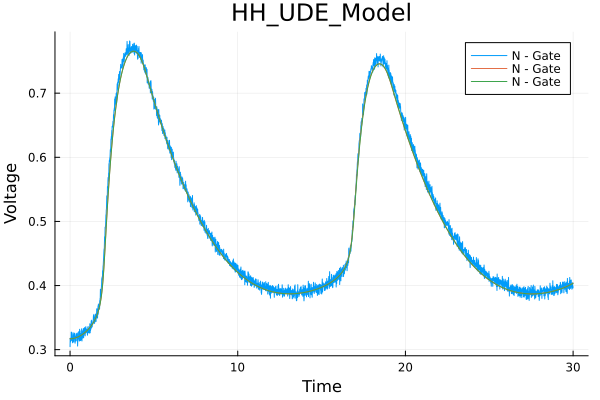

In [96]:
plot!(sol.t,sol[4, :],plot_title="HH_UDE_Model",label = "N - Gate")

## Defining the basis function 

In [70]:
# 9. Diverse Candidate Basis Functions Library (28 Functions)
basis_func = [
    n -> 1.0,
    n -> n,
    n -> n^2,
    n -> n^3,
    n -> n^4,
    n -> n^5,
    n -> n^6,
    n -> n^7,
    n -> n^8,
    n -> sqrt(max(0.0, n)),
    n -> sin(n),
    n -> cos(n),
    n -> sin(2 * n),
    n -> cos(2 * n),
    n -> sin(3 * n),
    n -> cos(3 * n),
    n -> sin(pi * n),
    n -> cos(pi * n),
    n -> exp(n),
    n -> exp(-n),
    n -> exp(2 * n),
    n -> exp(-2 * n),
    n -> sinh(n),
    n -> cosh(n),
    n -> tanh(n),
    n -> log(1.0 + max(0.0, n)),
    n -> 1.0 / (1.0 + n),
    n -> n / (1.0 + n)
]

28-element Vector{Function}:
 #209 (generic function with 1 method)
 #211 (generic function with 1 method)
 #213 (generic function with 1 method)
 #215 (generic function with 1 method)
 #217 (generic function with 1 method)
 #219 (generic function with 1 method)
 #221 (generic function with 1 method)
 #223 (generic function with 1 method)
 #225 (generic function with 1 method)
 #227 (generic function with 1 method)
 #229 (generic function with 1 method)
 #231 (generic function with 1 method)
 #233 (generic function with 1 method)
 ⋮
 #241 (generic function with 1 method)
 #243 (generic function with 1 method)
 #245 (generic function with 1 method)
 #247 (generic function with 1 method)
 #249 (generic function with 1 method)
 #251 (generic function with 1 method)
 #253 (generic function with 1 method)
 #255 (generic function with 1 method)
 #257 (generic function with 1 method)
 #259 (generic function with 1 method)
 #261 (generic function with 1 method)
 #263 (generic function with 1 m

## Basis function names

In [71]:
basis_names = [
    "1", "n", "n^2", "n^3", "n^4", "n^5", "n^6", "n^7", "n^8",
    "sqrt(n)",
    "sin(n)", "cos(n)", "sin(2n)", "cos(2n)", "sin(3n)", "cos(3n)", "sin(πn)", "cos(πn)",
    "exp(n)", "exp(-n)", "exp(2n)", "exp(-2n)", "sinh(n)", "cosh(n)", "tanh(n)",
    "log(1+n)", "1/(1+n)", "n/(1+n)"
]

28-element Vector{String}:
 "1"
 "n"
 "n^2"
 "n^3"
 "n^4"
 "n^5"
 "n^6"
 "n^7"
 "n^8"
 "sqrt(n)"
 "sin(n)"
 "cos(n)"
 "sin(2n)"
 ⋮
 "sin(πn)"
 "cos(πn)"
 "exp(n)"
 "exp(-n)"
 "exp(2n)"
 "exp(-2n)"
 "sinh(n)"
 "cosh(n)"
 "tanh(n)"
 "log(1+n)"
 "1/(1+n)"
 "n/(1+n)"

## 10. Construct Design Matrix (ϕ)


In [72]:
basis_l = length(basis_func)
n = sol[4, :]
point_l = length(n)
ϕ = [basis_func[i](n[j]) for j in 1:point_l, i in 1:basis_l]

3001×28 Matrix{AbstractFloat}:
 1.0  0.317     0.100489  0.031855   …  0.275356  0.759301  0.240699
 1.0  0.317003  0.100491  0.0318558     0.275358  0.7593    0.2407
 1.0  0.317008  0.100494  0.0318574     0.275362  0.759297  0.240703
 1.0  0.317016  0.100499  0.0318597     0.275368  0.759292  0.240708
 1.0  0.317026  0.100506  0.0318629     0.275376  0.759286  0.240714
 1.0  0.317039  0.100514  0.0318668  …  0.275386  0.759279  0.240721
 1.0  0.317055  0.100524  0.0318716     0.275398  0.75927   0.24073
 1.0  0.317073  0.100535  0.0318771     0.275412  0.759259  0.240741
 1.0  0.317094  0.100549  0.0318833     0.275428  0.759247  0.240753
 1.0  0.317117  0.100563  0.0318904     0.275446  0.759234  0.240766
 1.0  0.317143  0.10058   0.0318982  …  0.275465  0.759219  0.240781
 1.0  0.317172  0.100598  0.0319068     0.275487  0.759202  0.240798
 1.0  0.317203  0.100618  0.0319162     0.27551   0.759185  0.240815
 ⋮                                   ⋱  ⋮                   
 1.0  0.40219 

## Neural Network prediction 

In [73]:

y = Float64[nn(@SVector[n[j]], ps, st)[1][1] for j in 1:length(n)]
β = ϕ \ y
num_basis = size(ϕ, 2)


28

### Using Lasse Regresser


In [74]:
λ = 0.1

0.1

### normalizing the desing matrix to that low value do get squezied by λ each element in ϕ

In [77]:

col_norms = [ norm(ϕ[ : , i]) for i in 1 : size(ϕ,2) ]

ϕ_std = ϕ ./ col_norms'

3001×28 Matrix{AbstractFloat}:
 0.0182544  0.0113727  0.00623185  …  0.0123949  0.0204768  0.0133215
 0.0182544  0.0113728  0.00623195     0.012395   0.0204768  0.0133216
 0.0182544  0.011373   0.00623215     0.0123952  0.0204767  0.0133217
 0.0182544  0.0113732  0.00623246     0.0123954  0.0204766  0.013322
 0.0182544  0.0113736  0.00623287     0.0123958  0.0204764  0.0133223
 0.0182544  0.0113741  0.00623339  …  0.0123962  0.0204762  0.0133227
 0.0182544  0.0113746  0.006234       0.0123968  0.020476   0.0133232
 0.0182544  0.0113753  0.00623472     0.0123974  0.0204757  0.0133238
 0.0182544  0.011376   0.00623554     0.0123981  0.0204754  0.0133245
 0.0182544  0.0113769  0.00623646     0.0123989  0.020475   0.0133252
 0.0182544  0.0113778  0.00623748  …  0.0123998  0.0204746  0.0133261
 0.0182544  0.0113788  0.0062386      0.0124008  0.0204742  0.013327
 0.0182544  0.01138    0.00623982     0.0124018  0.0204737  0.013328
 ⋮                                 ⋱  ⋮                     
 

## DEFINING THE PROBLEM

In [78]:
β_std = Variable(num_basis)
problem = minimize(sumsquares(ϕ_std * β_std - y) + λ * norm(β_std, 1))


Problem statistics
  problem is DCP         : true
  number of variables    : 1 (28 scalar elements)
  number of constraints  : 0 (0 scalar elements)
  number of coefficients : 87_031
  number of atoms        : 7

Solution summary
  termination status : OPTIMIZE_NOT_CALLED
  primal status      : NO_SOLUTION
  dual status        : NO_SOLUTION

Expression graph
  minimize
   └─ + (convex; positive)
      ├─ qol (convex; positive)
      │  ├─ + (affine; real)
      │  │  ├─ …
      │  │  └─ …
      │  └─ [1;;]
      └─ * (convex; positive)
         ├─ [0.1;;]
         └─ sum (convex; positive)
            └─ …


### SOLVING THE ABOVE PROBLEM USING  ( SCS ) SOLVER

### and unscaling the coefficients

In [79]:
Convex.solve!(problem, SCS.Optimizer; silent=true)
β_lasso = vec(evaluate(β_std)) ./ col_norms

28-element Vector{Float64}:
  2.585115353017223e-6
  4.9695410055178565e-6
  5.82640226590582e-6
  0.23091144503541514
  0.7169211894171167
 -2.1178058695221382e-5
 -4.436907324902784e-5
 -7.804317033251335e-5
 -0.0001256650140487322
  3.7908859184693727e-6
  5.483904413608684e-6
  3.0305227534883334e-6
  3.636911303640743e-6
  ⋮
  3.7629815964568036e-6
 -0.01931384282419297
  1.4909155244986904e-6
  3.980576584884475e-6
  7.422908882279849e-7
  5.542428099158903e-6
  4.4940174230764675e-6
  2.1972467930473137e-6
  5.850504072084977e-6
  6.521525437010725e-6
  3.687061351326671e-6
  8.234233530733964e-6

## REFIT (OLS)  to eliminate lasso shrinkage bias

In [80]:
active_mask = abs.(β_lasso) .> 0.1
β_opt = zeros(num_basis)
if sum(active_mask) > 0
    β_opt[active_mask] = ϕ[:, active_mask] \ y
end


2-element Vector{Float64}:
 0.08431600834621814
 0.974871785221913

### SYMBOLIC REGRESSION RESULTS

In [84]:
println("\nCalculated Basis Coefficients (β):")
for (name, val) in zip(basis_names, β_opt)
    @printf("  %-5s : %10.5f\n", name, val)
end


Calculated Basis Coefficients (β):
  1     :    0.00000
  n     :    0.00000
  n^2   :    0.00000
  n^3   :    0.08432
  n^4   :    0.97487
  n^5   :    0.00000
  n^6   :    0.00000
  n^7   :    0.00000
  n^8   :    0.00000
  sqrt(n) :    0.00000
  sin(n) :    0.00000
  cos(n) :    0.00000
  sin(2n) :    0.00000
  cos(2n) :    0.00000
  sin(3n) :    0.00000
  cos(3n) :    0.00000
  sin(πn) :    0.00000
  cos(πn) :    0.00000
  exp(n) :    0.00000
  exp(-n) :    0.00000
  exp(2n) :    0.00000
  exp(-2n) :    0.00000
  sinh(n) :    0.00000
  cosh(n) :    0.00000
  tanh(n) :    0.00000
  log(1+n) :    0.00000
  1/(1+n) :    0.00000
  n/(1+n) :    0.00000


In [1]:
# Filter out small numerical noise (< 0.01 threshold)
threshold = 0.1
active_terms = String[]

String[]

In [90]:
for (name, val) in zip(basis_names, β_opt)
    if abs(val) > threshold
        push!(active_terms, @sprintf("%.4f * %s", val, name))
    end
end

# OUR RECOVERED TERM 

In [91]:
recovered_eq = isempty(active_terms) ? "0.0" : join(active_terms, " + ")


"0.9749 * n^4"